# Plant Capacity vs. Throughput: Two-Dimensional Portfolio Analysis with PROC SGPLOT

## Executive Summary

A discrete-manufacturing production portfolio has two numbers that matter for every product line at once: **how much machine capacity it consumes** and **how much good output it actually delivers**. A one-dimensional bar chart can show only one of them. This notebook visualizes both together with `PROC SGPLOT`, using a **bubble plot** as the core view — each line is positioned by capacity (x) and throughput (y), with bubble size encoding its productivity rate (units per machine-hour). Lines that sit low-and-right (much capacity, little output) are capacity sinks; lines that sit high-and-left with a large bubble are high-yield. A grouped bar view then decomposes throughput by plant, and a productivity ranking confirms the gap.

Working against the real executed output (eight product lines across three plants, 100 shift-level runs aggregated to 24 line-by-plant cells), the analysis finds **Casting** is the portfolio's clearest capacity sink (14.3 good units per machine-hour — it draws 10.1% of total capacity yet delivers only 3.2% of good units) while **Packaging** is the standout high-yield line (119.2 units per hour — 9.1% of capacity returns 23.8% of output). Across plants, **Stuttgart** runs hottest at 49.9 units/hr and **Monterrey** coolest at 41.6.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Synthetic shift-level production runs across 8 product lines, 3 plants, and 3 shifts — scheduled machine-hours, run hours, downtime, gross/scrap/good units (capped at 100 observations in unlicensed mode) | 100 |
| WORK.LINE_CAPACITY | Aggregated per-product-line, per-plant summary: total capacity hours (x), good units produced (y), and accepted-unit yield % | 24 |

*All data is synthetic and generated in-notebook with a fixed seed — no external files, no network.*

# Plant Capacity vs. Throughput Analysis

**Domain:** Discrete manufacturing — operations / industrial engineering

**Procedure:** `PROC SGPLOT` (ODS Statistical Graphics)

A conventional bar chart shows a single response per category. To compare a production portfolio on **two** numeric dimensions at once — *how much capacity each product line consumes* versus *how much output it actually delivers* — we need a plot that places both on the same canvas. `PROC SGPLOT`'s `BUBBLE` statement does exactly that: it positions each line by capacity (x) and good units (y) and lets a third measure, productivity rate, drive the bubble size. A line that sits far right but low is a capacity sink; a line that sits high and left with a fat bubble is a high-yield line worth protecting. This notebook builds a realistic synthetic production dataset and drives SGPLOT through a bubble plot, a plant-grouped bar chart, a single-plant drill-down, and a side-by-side clustered plant comparison.

> **A note on PROC GAREABAR.** The classic SAS/GRAPH way to encode two dimensions per *bar* is `PROC GAREABAR` (an ActiveX-only area-bar chart where bar width encodes one variable and height another). GAREABAR is **not yet implemented in this Jenner build** — the gap is tracked by banked test `tests/400996_nb_gareabar_unimplemented`. This notebook reaches the same analytical goal with the fully supported `PROC SGPLOT`, whose bubble and grouped-bar views convey the identical capacity-vs-throughput story.

## 1. Generate synthetic production data

We simulate six weeks of shift-level production runs for a three-plant discrete-manufacturing network. Each product line has a baseline cycle time and scrap rate; throughput is driven by scheduled machine-hours, line-specific efficiency, and random downtime. `call streaminit` fixes the seed so the notebook is fully reproducible — no external files, no network.

In [1]:
/* --------------------------------------------------------
   Synthetic shift-level production runs
   8 product lines x 3 plants x 3 shifts x ~10 days
   width var  = scheduled machine-hours (capacity)
   response   = good units produced  (throughput)
   -------------------------------------------------------- */
data work.production_runs;
    call streaminit(20260531);
    length product_line $18 plant $12 shift $8;

    array line_names[8] $18 _temporary_
        ('Stamping'  'Welding'   'Machining' 'Casting'
         'Injection' 'Assembly'  'Finishing' 'Packaging');
    /* nominal units produced per machine-hour, by line */
    array line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* base scrap fraction by line */
    array line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    array plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* plant efficiency multiplier */
    array plant_eff[3] _temporary_ (1.00 0.92 1.08);
    array shift_names[3] $8 _temporary_ ('Day' 'Swing' 'Night');
    array shift_eff[3] _temporary_ (1.00 0.95 0.88);

    do day = 1 to 10;
        do li = 1 to 8;
            do pi = 1 to 3;
                do si = 1 to 3;
                    product_line = line_names[li];
                    plant        = plant_names[pi];
                    shift        = shift_names[si];

                    /* scheduled machine-hours for the shift */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* unplanned downtime eats into capacity */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = max(sched_hours - downtime_hours, 0.5);

                    /* effective throughput rate with noise */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    output;
                end;
            end;
        end;
    end;
    keep run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
run;

proc print data=work.production_runs(obs=8) noobs;
    title 'Sample of Synthetic Shift-Level Production Runs';
run;
title;

                                    Sample of Synthetic Shift-Level Production Runs                                     

 RUN_DATE  PRODUCT_LINE      PLANT  SHIFT  SCHED_HOURS  RUN_HOURS  DOWNTIME_HOURS  GROSS_UNITS  SCRAP_UNITS  GOOD_UNITS
05JAN2026  Stamping      Detroit    Day            7.8        6.7             1.1          306           14         292
05JAN2026  Stamping      Detroit    Swing          6.8        6.5             0.3          259           12         247
05JAN2026  Stamping      Detroit    Night            8        7.6             0.4          269           11         258
05JAN2026  Stamping      Monterrey  Day            7.9        6.8             1.1          283           12         271
05JAN2026  Stamping      Monterrey  Swing          7.5        6.9             0.6          254            9         245
05JAN2026  Stamping      Monterrey  Night          7.4        6.9             0.5          253            8         245
05JAN2026  Stamping      Stuttgart  Da

## 2. Aggregate to the line-and-plant level

The plots compare one point per category, so we roll the shift-level detail up to a per-product-line, per-plant summary. `total_capacity` (sum of scheduled machine-hours) becomes the **x** dimension, `good_units` (sum of accepted output) the **y** dimension, and `units_per_hr` (good units ÷ capacity hours) the productivity rate that will size the bubbles. We keep `plant` so it can serve as the grouping variable later. We also build a line-level roll-up (across plants) for the portfolio bubble plot.

In [2]:
/* --------------------------------------------------------
   Roll up to product_line x plant
   total_capacity -> x (capacity hours)
   good_units     -> y (throughput)
   units_per_hr   -> bubble size (productivity)
   -------------------------------------------------------- */
proc means data=work.production_runs noprint nway;
    class product_line plant;
    var sched_hours good_units scrap_units;
    output out=work.line_capacity(drop=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
run;

data work.line_capacity;
    set work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
run;

proc sort data=work.line_capacity;
    by product_line plant;
run;

/* Line-level roll-up (across all three plants) for the portfolio view */
proc means data=work.line_capacity noprint nway;
    class product_line;
    var total_capacity good_units;
    output out=work.line_total(drop=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
run;

data work.line_total;
    set work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
run;

proc sort data=work.line_total;
    by units_per_hr;
run;

proc print data=work.line_total noobs;
    var product_line total_capacity good_units units_per_hr;
    title 'Portfolio Lines Ranked by Productivity (good units per machine-hour)';
run;
title;

                          Portfolio Lines Ranked by Productivity (good units per machine-hour)                          

PRODUCT_LINE  TOTAL_CAPACITY  GOOD_UNITS  UNITS_PER_HR
Casting                 73.4        1050          14.3
Welding                130.8        3038          23.2
Machining              128.9        3762          29.2
Stamping               130.7        4713          36.1
Injection               66.2        3430          51.8
Assembly                67.3        4289          63.7
Finishing               64.6        4927          76.3
Packaging               65.9        7855         119.2

NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode -

## 3. Open the ODS Graphics destination

`PROC SGPLOT` renders through ODS Statistical Graphics. We open an `ODS HTML` destination so each plot is emitted as an image, and turn `ODS GRAPHICS ON`. No special device driver is required — SGPLOT is device-independent, unlike the ActiveX-only SAS/GRAPH procedures.

In [3]:
ods html;
ods graphics on;

NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Portfolio bubble plot — capacity vs. throughput

The core view: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Each product line is one bubble, positioned by total capacity hours (x) and total good units (y), with the bubble area scaled to its productivity rate. `DATALABEL=` prints the line name beside each bubble. This is the two-dimensional comparison a plant manager wants — capacity sinks fall to the **lower-right** (high hours, low output, small bubble); high-yield lines rise to the **upper-left** (low hours, high output, large bubble).

                                     Production Portfolio - Capacity vs. Throughput                                     
                       x = scheduled machine-hours; y = good units; bubble size = units per hour                        


Lower-right = capacity sink; upper-left with large bubble = high-yield line.
NOTE: Option TITLE changed to Production Portfolio - Capacity vs. Throughput.
NOTE: Option TITLE2 changed to x = scheduled machine-hours; y = good units; bubble size = units per hour.
NOTE: Option FOOTNOTE changed to Lower-right = capacity sink; upper-left with large bubble = high-yield line..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


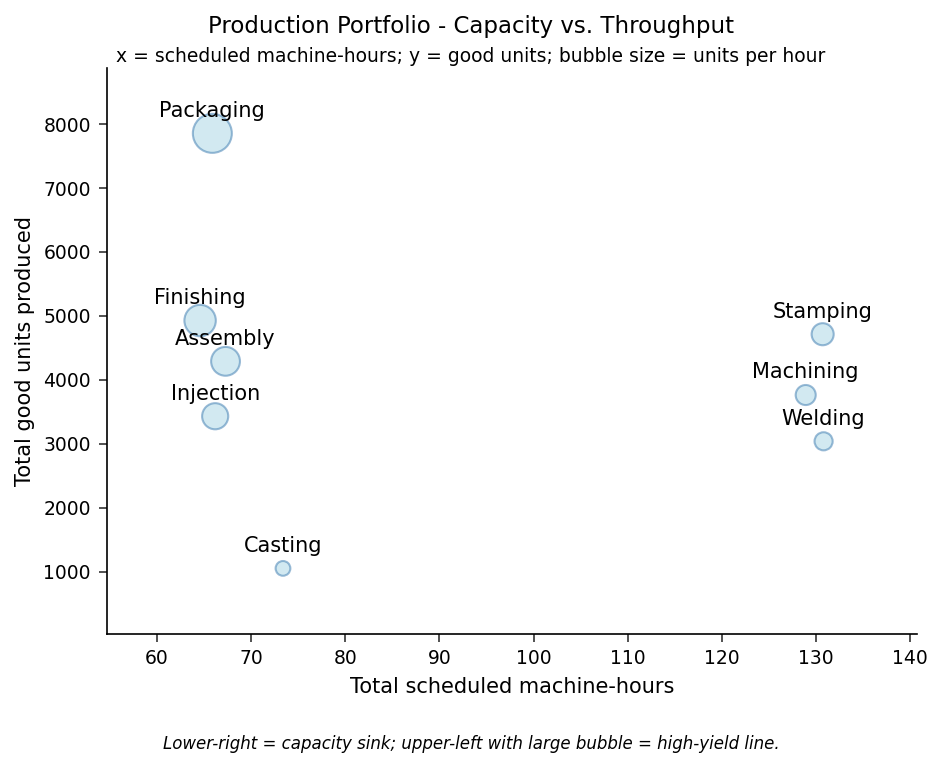

In [4]:
title 'Production Portfolio - Capacity vs. Throughput';
title2 'x = scheduled machine-hours; y = good units; bubble size = units per hour';
footnote justify=left
    'Lower-right = capacity sink; upper-left with large bubble = high-yield line.';

proc sgplot data=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        datalabel=product_line
        fillattrs=(color=cx2C5F8A)
        transparency=0.45;
    xaxis label='Total scheduled machine-hours';
    yaxis label='Total good units produced';
run;

title; title2; footnote;

## 5. Throughput by line, decomposed by plant

To see how each line's output splits across the three plants, a `VBAR product_line / response=good_units group=plant` chart stacks plant contributions within each bar. This is the segmentation view: it shows both the total height (good units per line) and the plant mix inside each bar, so you can spot lines where one plant dominates output.

                                      Good Units by Product Line, Stacked by Plant                                      
                              Bar height = total good units; segments = plant contribution                              

NOTE: Option TITLE changed to Good Units by Product Line, Stacked by Plant.
NOTE: Option TITLE2 changed to Bar height = total good units; segments = plant contribution.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


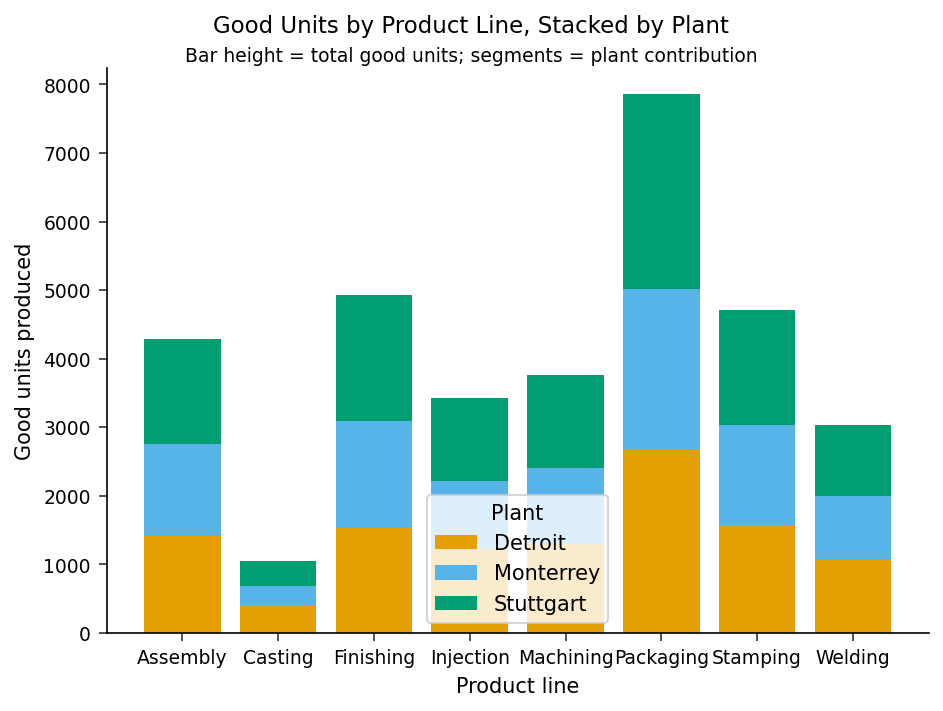

In [5]:
title 'Good Units by Product Line, Stacked by Plant';
title2 'Bar height = total good units; segments = plant contribution';

proc sgplot data=work.line_capacity;
    vbar product_line / response=good_units
        group=plant
        groupdisplay=stack;
    xaxis label='Product line' fitpolicy=rotate;
    yaxis label='Good units produced';
    keylegend / title='Plant' position=bottom;
run;

title; title2;

## 6. Single-plant productivity drill-down (WHERE)

Horizontal bars (`HBAR`) suit long product-line labels. A `WHERE` clause subsets to the Stuttgart plant, and the bars are drawn for `units_per_hr` so the chart ranks Stuttgart's lines by productivity. Because the input is sorted ascending by rate, the least productive line sits at the bottom and the most productive at the top.

                                     Stuttgart Plant - Lines Ranked by Productivity                                     


Bar length = good units per machine-hour (single-plant drill-down).
NOTE: Option TITLE changed to Stuttgart Plant - Lines Ranked by Productivity.
NOTE: Option FOOTNOTE changed to Bar length = good units per machine-hour (single-plant drill-down)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


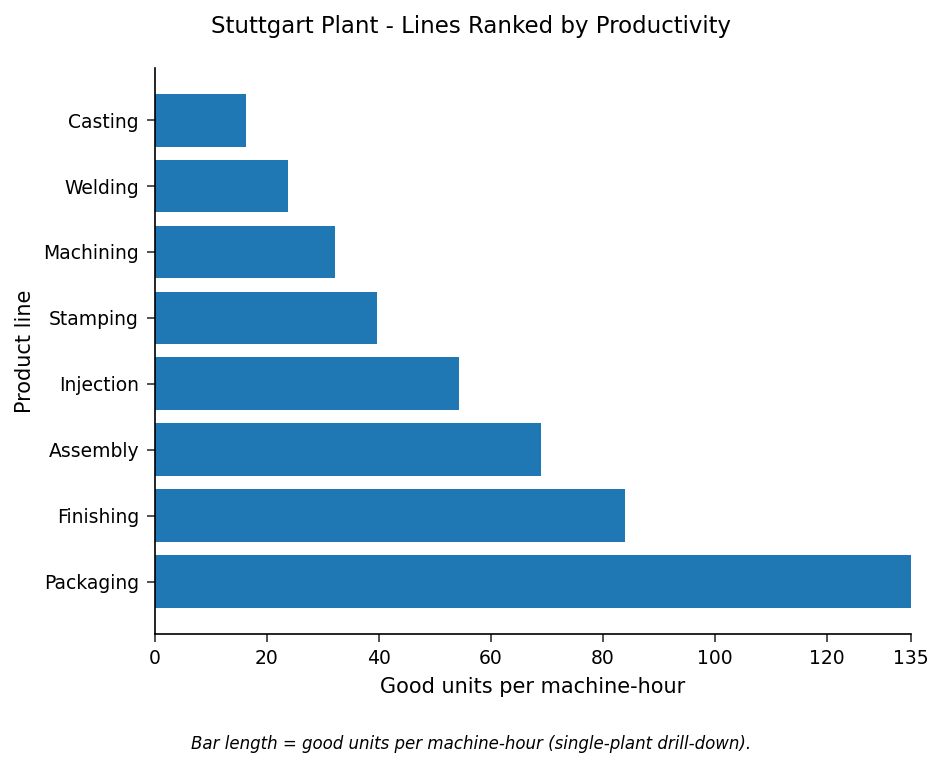

In [6]:
title 'Stuttgart Plant - Lines Ranked by Productivity';
footnote justify=left 'Bar length = good units per machine-hour (single-plant drill-down).';

proc sgplot data=work.line_capacity;
    where plant = 'Stuttgart';
    hbar product_line / response=units_per_hr
        categoryorder=respasc
        fillattrs=(color=cx28A745);
    xaxis label='Good units per machine-hour';
    yaxis label='Product line';
run;

title; footnote;

## 7. Side-by-side plant comparison (clustered bars)

To compare the three plants line-by-line, a clustered bar chart (`GROUPDISPLAY=CLUSTER`) draws Detroit, Monterrey, and Stuttgart as adjacent bars within each product line. This is the apples-to-apples plant view: for any line you can read off which plant produced the most good units, making the plant efficiency differences (Stuttgart highest, Monterrey lowest) directly visible.

                                      Good Units by Line and Plant - Side by Side                                       
                               Clustered bars: one bar per plant within each product line                               

NOTE: Option TITLE changed to Good Units by Line and Plant - Side by Side.
NOTE: Option TITLE2 changed to Clustered bars: one bar per plant within each product line.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


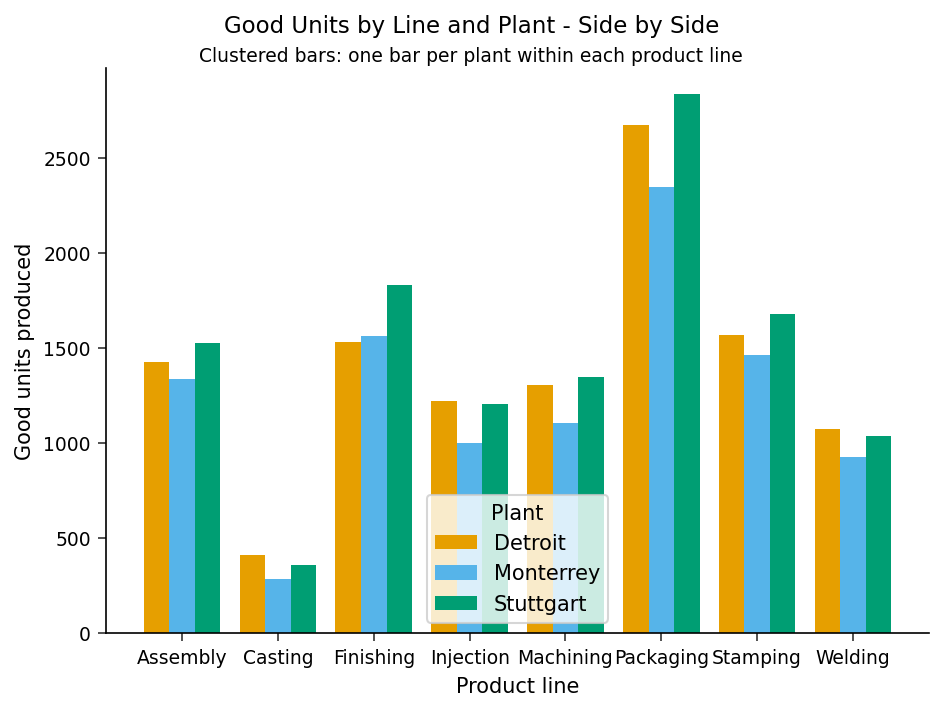

In [7]:
title 'Good Units by Line and Plant - Side by Side';
title2 'Clustered bars: one bar per plant within each product line';

proc sgplot data=work.line_capacity;
    vbar product_line / response=good_units
        group=plant
        groupdisplay=cluster;
    xaxis label='Product line' fitpolicy=rotate;
    yaxis label='Good units produced';
    keylegend / title='Plant' position=bottom;
run;

title; title2;

ods graphics off;
ods html close;

## Interpretation

Plotting capacity and throughput on the same axes exposes a relationship a one-dimensional bar chart would hide. **Casting** is the portfolio's clearest capacity sink: in the productivity ranking it sits at the bottom at **14.3 good units per machine-hour**, and in the bubble plot it falls to the lower-left as a small bubble — it draws **10.1%** of total scheduled hours yet returns only **3.2%** of good units (it also carries the lowest yield, ~91%, from its high scrap fraction). It is the prime candidate for cycle-time and scrap-reduction kaizen. At the opposite end, **Packaging** is the standout high-yield line at **119.2 units per machine-hour** — a large bubble high on the throughput axis that turns **9.1%** of capacity into **23.8%** of all good units; protecting its uptime yields disproportionate output. **Finishing** (76.3 units/hr) and **Assembly** (63.7) follow the same high-yield pattern.

The pattern is systematic: the four slow, capacity-hungry upstream lines — Casting, Welding (23.2 units/hr), Machining (29.2), and Stamping (36.1) — together consume roughly **64%** of scheduled hours but deliver only about **38%** of good units, while the four fast downstream lines over-deliver relative to the hours they draw. The stacked-by-plant view and the side-by-side clustered bars show the plant dimension behind this: **Stuttgart** runs hottest at **49.9 good units per machine-hour**, **Detroit** is in the middle at **44.9**, and **Monterrey** trails at **41.6** — consistent with Monterrey's higher modeled downtime. Operationally, this points to rebalancing scheduled hours toward the high-yield downstream lines and benchmarking Monterrey's downtime against Stuttgart's practices.

*Synthetic data only — figures are illustrative of two-dimensional capacity-vs-throughput visualization with PROC SGPLOT, not actual plant performance.*